In [1]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)


2025-02-09 18:15:05.805207: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-09 18:15:05.820223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739121305.837654   31484 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739121305.843003   31484 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-09 18:15:05.863012: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# Laden der Daten
df = pd.read_csv('../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv')
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S')
df = df.set_index('time')
df = df.resample('d').sum()
y = df['weg_auf_dem_damm']
y = y.values.reshape(-1, 1)
df.head()

,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer
time,,,,,,,,,
2016-01-16,256,50,2212,173,333,249,210,271,361
2016-01-17,164,59,1533,230,358,316,220,339,358
2016-01-18,559,145,5055,442,1633,783,566,792,1387
2016-01-19,581,151,6233,483,1658,770,586,743,1279
2016-01-20,513,141,5167,425,1543,668,505,612,1199


In [3]:
# Daten skallieren
scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(y)
y = scaler.transform(y)

In [4]:
# Input generieren
n_lookback = 28  # Länge des Inputs für die Vorhersage
n_forecast = 7 # Länge der Vorhersage

X = []
Y = []

for i in range(n_lookback, len(y) - n_forecast + 1):
    X.append(y[i - n_lookback: i])
    Y.append(y[i: i + n_forecast])

X = np.array(X)
Y = np.array(Y)

In [5]:
# Das Model trainieren
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(n_lookback, 1)))
model.add(LSTM(units=50))
model.add(Dense(n_forecast))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
early = EarlyStopping(monitor='val_loss', patience=10)
check = ModelCheckpoint(filepath='weg_auf_dem_damm.keras', monitor='val_loss', save_best_only=True)
damm = model.fit(X, Y, batch_size=32, epochs=100, shuffle=True, validation_split = 0.1, callbacks=[early, check], verbose=1)

Epoch 1/100


2025-02-09 18:15:07.676103: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/leonidas/Uni/Semester_5_24_25/Datenanalyse/Projekt/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0373 - mae: 0.1487 - val_loss: 0.0227 - val_mae: 0.1235
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0229 - mae: 0.1194 - val_loss: 0.0225 - val_mae: 0.1220
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0222 - mae: 0.1172 - val_loss: 0.0221 - val_mae: 0.1208
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0223 - mae: 0.1167 - val_loss: 0.0222 - val_mae: 0.1224
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0224 - mae: 0.1177 - val_loss: 0.0219 - val_mae: 0.1223
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0212 - mae: 0.1141 - val_loss: 0.0210 - val_mae: 0.1165
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0214 - mae: 0.1136 - val_loss: 0.0217 - val_mae: 0.1174
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0211 - mae: 0.1122 - val_loss: 0.0212 - val_mae: 0.1183
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0208 - mae: 0.

In [6]:
# Vorhersage
X_ = y[- n_lookback:]
X_ = X_.reshape(1, n_lookback, 1)

Y_ = model.predict(X_).reshape(-1, 1)
Y_ = scaler.inverse_transform(Y_)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


In [7]:
# Ergebnisse organisieren
df_past = df[['weg_auf_dem_damm']].reset_index()
df_past['time'] = pd.to_datetime(df_past['time'])
df_past['Forecast'] = np.nan
df_past['Forecast'].iloc[-1] = df_past['weg_auf_dem_damm'].iloc[-1]
df_past

KeyError: 'weg_auf_dem_damm'

In [8]:
df_future = pd.DataFrame(columns=['time', 'weg_auf_dem_damm', 'Forecast'])
df_future['time'] = pd.date_range(start=df_past['time'].iloc[-1] + pd.Timedelta(hours=1), periods=n_forecast)
df_future['Forecast'] = Y_.flatten()
df_future['weg_auf_dem_damm'] = np.nan
df_future

,time,von_sandt_ufer,Forecast
0,2023-12-31 01:00:00,NaN,1222.155273
1,2024-01-01 01:00:00,NaN,1902.017700
2,2024-01-02 01:00:00,NaN,2281.644775
3,2024-01-03 01:00:00,NaN,2559.142090
4,2024-01-04 01:00:00,NaN,2339.514404
5,2024-01-05 01:00:00,NaN,2459.172852
6,2024-01-06 01:00:00,NaN,2056.640137


In [9]:
results = pd.concat([df_past, df_future])
results = results.set_index('time')
results.head()

,von_sandt_ufer,Forecast
time,,
2016-01-16,210.0,NaN
2016-01-17,220.0,NaN
2016-01-18,566.0,NaN
2016-01-19,586.0,NaN
2016-01-20,505.0,NaN


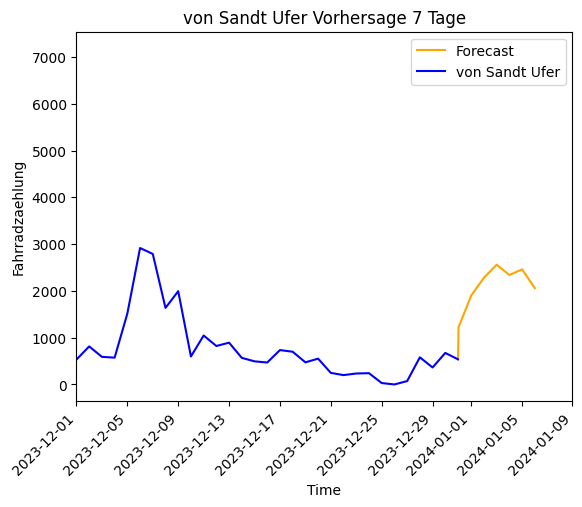

In [10]:
# Ergebnisse plotten
plt.plot(results['Forecast'], color = 'orange', label = 'Forecast')
plt.plot(results['weg_auf_dem_damm'], color = 'blue', label = 'Weg auf dem Damm')
plt.title('Weg auf dem Damm Vorhersage 7 Tage')
plt.xlabel('Time')
plt.ylabel('Fahrradzaehlung')
plt.legend()
start_date = datetime(2023, 12, 1)
end_date = datetime(2024, 1, 9)
plt.xlim(start_date, end_date)
#plt.ylim(0,1300)
plt.xticks(rotation=45, ha='right')
plt.show()

Text(0, 0.5, 'loss')

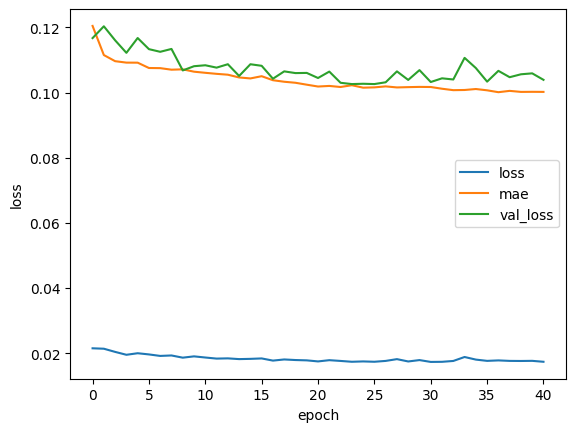

In [11]:
plt.plot(damm.history['val_loss'])
plt.plot(damm.history['mae'])
plt.plot(damm.history['val_mae'])
plt.legend(['loss', 'mae', 'val_loss', 'val_mae'])
plt.xlabel('epoch')
plt.ylabel('loss')

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 28, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,873 (362.79 KB)

 Trainable params: 30,957 (120.93 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,916 (241.86 KB)